In [1]:
import re
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm

c:\Users\jaese\Desktop\ml-webapp\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_data = pd.read_table('../dataset/sentiment_analysis_KOR/ratings_train.txt')
test_data = pd.read_table('../dataset/sentiment_analysis_KOR/ratings_test.txt')

train_data.drop_duplicates(subset=['document'],inplace=True)
train_data.dropna(how='any',inplace=True)
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
train_data['document'] = train_data['document'].str.replace('^ +', "", regex=True) # white space 데이터를 empty value로 변경
train_data['document'].replace('', np.nan, inplace=True)
train_data = train_data.dropna(how = 'any')

test_data.drop_duplicates(subset = ['document'], inplace=True) # document 열에서 중복인 내용이 있다면 중복 제거
test_data['document'] = test_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True) # 정규 표현식 수행
test_data['document'] = test_data['document'].str.replace('^ +', "", regex=True) # 공백은 empty 값으로 변경
test_data['document'].replace('', np.nan, inplace=True) # 공백은 Null 값으로 변경
test_data = test_data.dropna(how='any') # Null 값 제거
print(train_data.isnull().sum())

id          0
document    0
label       0
dtype: int64


C:\Users\jaese\AppData\Local\Temp\ipykernel_13348\1265497848.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['document'].replace('', np.nan, inplace=True)
C:\Users\jaese\AppData\Local\Temp\ipykernel_13348\1265497848.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    "monologg/koelectra-base-v3-discriminator"
)

lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in train_data['document']]
lengths


[10,
 20,
 3,
 14,
 39,
 23,
 13,
 59,
 14,
 27,
 14,
 29,
 25,
 28,
 33,
 12,
 38,
 19,
 23,
 18,
 22,
 14,
 67,
 15,
 12,
 25,
 10,
 8,
 6,
 17,
 27,
 12,
 13,
 12,
 12,
 10,
 26,
 15,
 12,
 13,
 10,
 39,
 13,
 22,
 46,
 15,
 64,
 32,
 8,
 75,
 31,
 22,
 16,
 24,
 4,
 6,
 3,
 51,
 5,
 9,
 14,
 18,
 17,
 49,
 26,
 63,
 42,
 25,
 18,
 19,
 12,
 67,
 4,
 14,
 7,
 25,
 16,
 4,
 24,
 5,
 21,
 9,
 31,
 9,
 8,
 8,
 6,
 7,
 13,
 15,
 10,
 15,
 7,
 15,
 8,
 16,
 6,
 11,
 12,
 20,
 26,
 13,
 18,
 13,
 10,
 24,
 5,
 7,
 15,
 19,
 19,
 23,
 12,
 3,
 28,
 6,
 8,
 9,
 19,
 8,
 46,
 29,
 16,
 7,
 4,
 14,
 8,
 25,
 67,
 19,
 5,
 12,
 7,
 22,
 14,
 14,
 20,
 9,
 25,
 25,
 4,
 18,
 66,
 5,
 9,
 10,
 56,
 35,
 19,
 71,
 13,
 3,
 20,
 7,
 6,
 7,
 41,
 20,
 10,
 3,
 14,
 24,
 11,
 63,
 81,
 23,
 8,
 25,
 16,
 5,
 47,
 66,
 18,
 10,
 7,
 29,
 7,
 6,
 19,
 13,
 62,
 10,
 62,
 9,
 25,
 3,
 12,
 8,
 46,
 11,
 7,
 25,
 22,
 31,
 34,
 24,
 9,
 28,
 16,
 39,
 13,
 18,
 12,
 84,
 23,
 15,
 19,
 7,
 27,
 8,
 6,
 

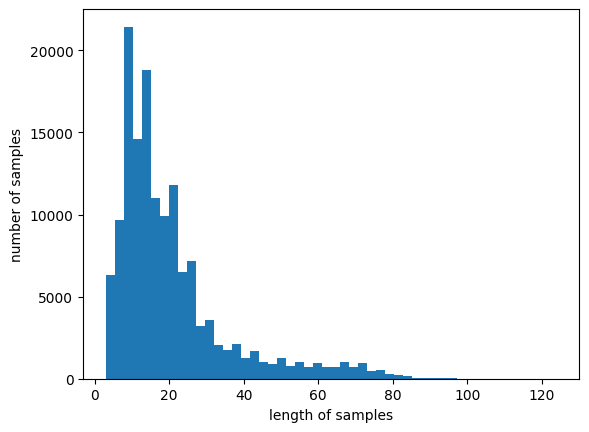

In [4]:
import matplotlib.pyplot as plt
plt.hist(lengths, bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [5]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):  #Dataset의 샘플 개수 반환
        return len(self.labels)

    
    def __getitem__(self, idx): 
        encoding = self.tokenizer(
            self.texts[idx],    # idx번째 문장을 토크나이즈
            padding="max_length", # max_length까지 0으로 패딩
            truncation=True, # max_length 초과 시 자름
            max_length=self.max_length,
            return_tensors="pt"  # PyTorch tensor 반환
        )
        
        #encoding은 BatchEncoding 타입 객체로, dict_keys(['input_ids', 'attention_mask'])를 가짐. 
        return {
            "input_ids": encoding["input_ids"].squeeze(0),  #input_ids = 토큰 id 리스트
            "attention_mask": encoding["attention_mask"].squeeze(0), 
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [6]:
X_train = np.array(train_data['document'])
X_test = np.array(test_data['document'])
y_train = np.array(train_data['label'])
y_test = np.array(test_data['label'])
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=1, stratify=y_train)

train_dataset = EmotionDataset(X_train, y_train, tokenizer)
val_dataset = EmotionDataset(X_valid, y_valid, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    "monologg/koelectra-base-v3-discriminator",
    num_labels=2,
    use_safetensors=True
)

model.to(device)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 924.88it/s, Materializing param=electra.encoder.layer.11.output.dense.weight]              
ElectraForSequenceClassification LOAD REPORT from: monologg/koelectra-base-v3-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignor

ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(35000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5,weight_decay=0.01)
epochs = 3
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)
def calculate_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    return correct / len(labels)

In [9]:
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

best_val_loss = float("inf")
patience = 2               #과적합 방지용 early stop
counter = 0
scaler = GradScaler()

for epoch in range(epochs):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    # progress bar for training
    train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for batch in train_iter:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # scheduler step per batch 
        scheduler.step()

        train_loss += loss.item()
        train_correct += (torch.argmax(logits, dim=1) == labels).sum().item()
        train_total += labels.size(0)

        train_iter.set_postfix(loss=train_loss/(train_total/labels.size(0)),
                                acc=train_correct/train_total)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            with autocast():
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss
                logits = outputs.logits

            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_f1 = f1_score(val_labels, val_preds, average='macro')

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        model.save_pretrained("../models/kor_sentiment_koelectra_model")
        print("best model saved")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

C:\Users\jaese\AppData\Local\Temp\ipykernel_13348\4122915664.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/3:   0%|          | 0/3635 [00:00<?, ?it/s]C:\Users\jaese\AppData\Local\Temp\ipykernel_13348\4122915664.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\jaese\AppData\Local\Temp\ipykernel_13348\4122915664.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/3
Train Loss: 0.3841 | Train Acc: 0.8156
Val   Loss: 0.2755 | Val   Acc: 0.8870 | Val F1: 0.8870


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.51it/s]


best model saved


Epoch 2/3:   0%|          | 0/3635 [00:00<?, ?it/s]C:\Users\jaese\AppData\Local\Temp\ipykernel_13348\4122915664.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\jaese\AppData\Local\Temp\ipykernel_13348\4122915664.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 2/3
Train Loss: 0.2564 | Train Acc: 0.8957
Val   Loss: 0.2598 | Val   Acc: 0.8940 | Val F1: 0.8940


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.06it/s]


best model saved


Epoch 3/3:   0%|          | 0/3635 [00:00<?, ?it/s]C:\Users\jaese\AppData\Local\Temp\ipykernel_13348\4122915664.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\jaese\AppData\Local\Temp\ipykernel_13348\4122915664.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 3/3
Train Loss: 0.2284 | Train Acc: 0.9087
Val   Loss: 0.2686 | Val   Acc: 0.8953 | Val F1: 0.8953


In [10]:
tokenizer.save_pretrained("../models/kor_sentiment_koelectra_model")

('../models/kor_sentiment_koelectra_model\\tokenizer_config.json',
 '../models/kor_sentiment_koelectra_model\\tokenizer.json')